<a href="https://colab.research.google.com/github/kjahan/stable_diffusion_demo/blob/master/notebooks/MidJourney_Style_Images_from_Fine_tuned_Stable_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Diffusion v1.5 vs Midjourney v4 Diffusion


https://huggingface.co/prompthero/midjourney-v4-diffusion

https://github.com/amrrs/midjourney4-stable-diffusion/blob/main/MidJourney_Style_Images_from_Fine_tuned_Stable_Diffusion.ipynb

https://www.youtube.com/watch?v=nYi1dE3qK6U

In [1]:
!pip install transformers diffusers accelerate -q

     |████████████████████████████████| 5.5 MB 26.8 MB/s 
     |████████████████████████████████| 304 kB 61.9 MB/s 
     |████████████████████████████████| 175 kB 70.7 MB/s 
     |████████████████████████████████| 7.6 MB 41.0 MB/s 
     |████████████████████████████████| 163 kB 48.6 MB/s 


In [12]:
from diffusers import StableDiffusionPipeline
import torch

import time

In [3]:
model_path = 'prompthero/midjourney-v4-diffusion'


In [4]:
pipe = StableDiffusionPipeline.from_pretrained(model_path , torch_dtype=torch.float16)


Downloading:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Downloading:   0%|          | 0.00/342 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/4.84k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

Downloading:   0%|          | 0.00/743 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/547 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/335M [00:00<?, ?B/s]

ftfy or spacy is not installed using BERT BasicTokenizer instead of ftfy.


In [5]:
!nvidia-smi


Sun Nov 13 20:00:27 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P8     9W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [6]:
if torch.cuda.is_available():
  pipe = pipe.to("cuda")

device = "GPU 🔥" if torch.cuda.is_available() else "CPU 🥶"

In [7]:
device

'GPU 🔥'

## Prompt

In [8]:
base_prompt = "a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting"  #@param {type:"string"}

#base_prompt = 'Close-up Portrait of a cyborg geisha, a glossy white, black, red, ivory porcelain face, mechanical features, cybernetic eyes, baroque, rococo, anodized titanium highly detailed mechanisms, gears, fiber, cogs, bulbs, wires, cables, 70mm, Canon EOS 6D Mark II, 4k, 35mm (FX, Full-Frame), f/2.5, extremely detailed, very high details, photorealistic, hi res, hdr, UHD, hyper-detailed, ultra-realistic, vibrant, centered, vivid colors, Wide angle, zoom out'


In [9]:
prompt = "mdjrny-v4 style " + base_prompt


In [10]:
prompt

'mdjrny-v4 style a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting'

In [11]:
result = pipe(
      prompt,  
      width = 512,
      height = 512)

  0%|          | 0/51 [00:00<?, ?it/s]

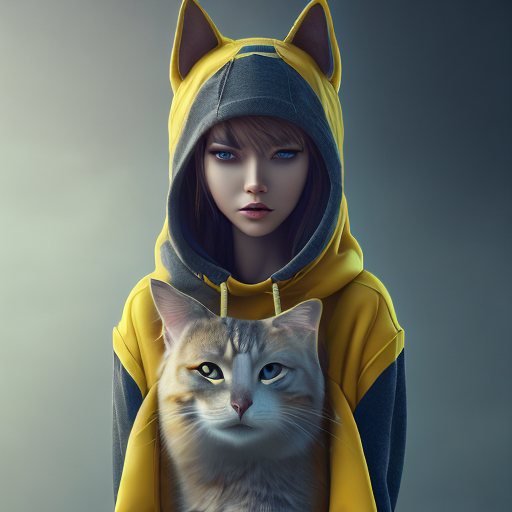

In [13]:
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

mdjrny-v4 style phantasmal iridescent portrait of awoman, detailed, colourful, psychedelic, unreal engine, octane render, blender effect


  0%|          | 0/51 [00:00<?, ?it/s]

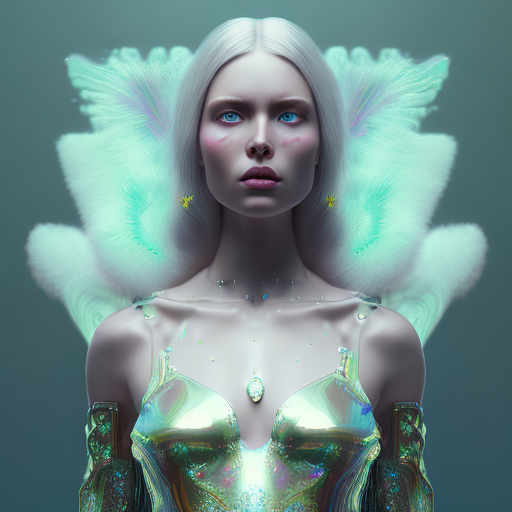

In [14]:
base_prompt = "phantasmal iridescent portrait of awoman, detailed, colourful, psychedelic, unreal engine, octane render, blender effect"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image


mdjrny-v4 style Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining


  0%|          | 0/51 [00:00<?, ?it/s]

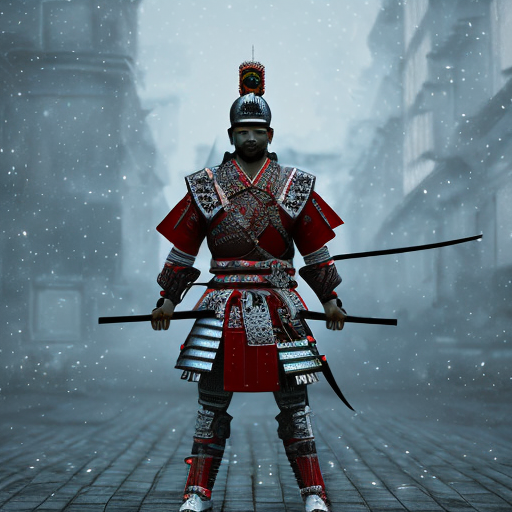

In [16]:
base_prompt = "Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

mdjrny-v4 style distant lightning storm


  0%|          | 0/51 [00:00<?, ?it/s]

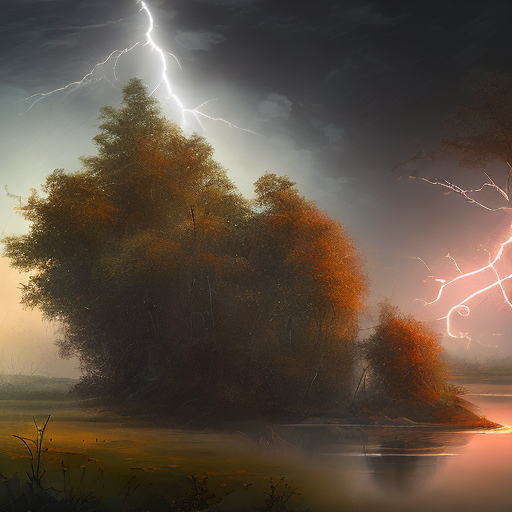

In [17]:
base_prompt = "distant lightning storm"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

mdjrny-v4 style A corgi riding a bike, ASCII art


  0%|          | 0/51 [00:00<?, ?it/s]

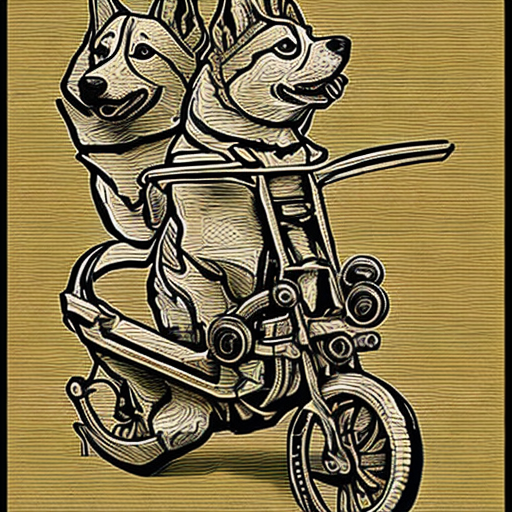

In [18]:
base_prompt = "A corgi riding a bike, ASCII art"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', 3 5 mm ( fx, full - frame ), f / 2. 5, extremely detailed, very high details, photorealistic, hi res, hdr, uhd, hyper - detailed, ultra - realistic, vibrant, centered, vivid colors, wide angle, zoom out <|endoftext|>']


mdjrny-v4 style Close-up Portrait of a cyborg geisha, a glossy white, black, red, ivory porcelain face, mechanical features, cybernetic eyes, baroque, rococo, anodized titanium highly detailed mechanisms, gears, fiber, cogs, bulbs, wires, cables, 70mm, Canon EOS 6D Mark II, 4k, 35mm (FX, Full-Frame), f/2.5, extremely detailed, very high details, photorealistic, hi res, hdr, UHD, hyper-detailed, ultra-realistic, vibrant, centered, vivid colors, Wide angle, zoom out


  0%|          | 0/51 [00:00<?, ?it/s]

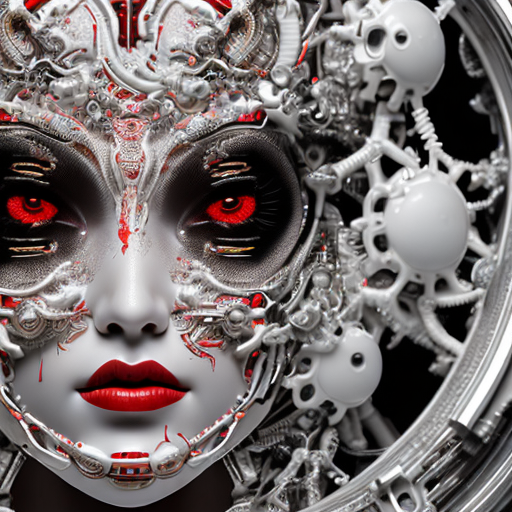

In [19]:
base_prompt = "Close-up Portrait of a cyborg geisha, a glossy white, black, red, ivory porcelain face, mechanical features, cybernetic eyes, baroque, rococo, anodized titanium highly detailed mechanisms, gears, fiber, cogs, bulbs, wires, cables, 70mm, Canon EOS 6D Mark II, 4k, 35mm (FX, Full-Frame), f/2.5, extremely detailed, very high details, photorealistic, hi res, hdr, UHD, hyper-detailed, ultra-realistic, vibrant, centered, vivid colors, Wide angle, zoom out"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

mdjrny-v4 style "Woman in Kimono" + "detailed, soft ambiance, japanese influence, unreal engine 5, octane render" + Remaster.


  0%|          | 0/51 [00:00<?, ?it/s]

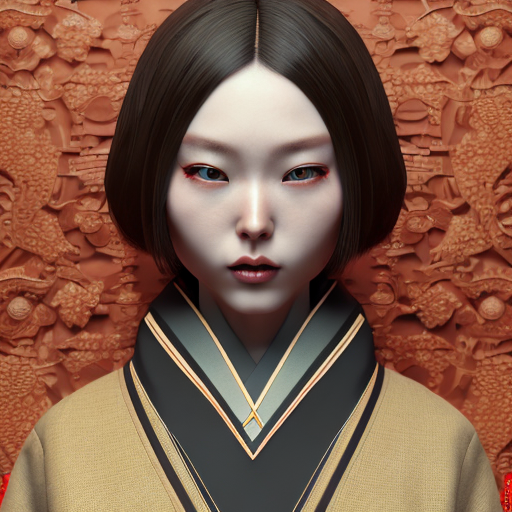

In [20]:
base_prompt = '"Woman in Kimono" + "detailed, soft ambiance, japanese influence, unreal engine 5, octane render" + Remaster.'

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,  
      width = 512,
      height = 512)
image = result.images[0]  
    
image.save("sd_img_{}.png".format(int(time.time())))

image

In [21]:
def generate_image(base_prompt):
  prompt = "mdjrny-v4 style " + base_prompt

  print(prompt)
  result = pipe(
        prompt,  
        width = 512,
        height = 512)
  image = result.images[0]  
      
  image.save("sd_img_{}.png".format(int(time.time())))

  return image

mdjrny-v4 style a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting --v 4


  0%|          | 0/51 [00:00<?, ?it/s]

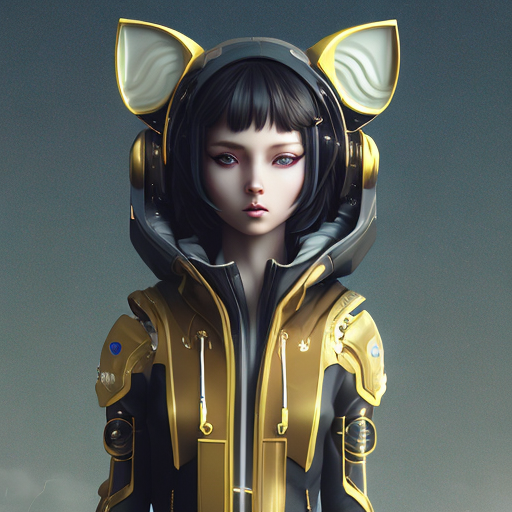

In [22]:
base_prompt = "a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting --v 4"

generate_image(base_prompt)